In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")

%matplotlib inline


In [4]:
# Load the data
data = pd.read_csv('/Users/rivaverma/Data Analysis/LinkedIn_Jobs_Data_India.csv')

In [5]:
# Show Top 5 Records
data.head(3)

,Unnamed: 0,id,publishedAt,title,companyName,postedTime,applicationsCount,description,contractType,experienceLevel,workType,sector,companyId,city,state,recently_posted_jobs
0,0,3800928381,2024-01-09,Front-end Engineer/Web Developer (SDE 1 &amp; 2),BOX8,3 weeks ago,85.0,"Skill: html5 , ajax , oop , git , postgresql ,...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
1,1,3800929078,2024-01-09,Android Developer-SDE 1 &amp; 2(Software Devel...,BOX8,3 weeks ago,80.0,"Skill: algorithms , rest , github , css , html...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
2,2,3792399495,2023-12-27,Web Developer,Mahe Technologies Private Limited,1 month ago,75.0,The ideal candidate is a creative problem solv...,Full-time,Executive,Engineering and Information Technology,Information Technology & Services,14387125,Greater Kolkata Area,NaN,No


In [6]:
# Returns the column labels of the DataFrame
data.columns

Index(['Unnamed: 0', 'id', 'publishedAt', 'title', 'companyName', 'postedTime',
       'applicationsCount', 'description', 'contractType', 'experienceLevel',
       'workType', 'sector', 'companyId', 'city', 'state',
       'recently_posted_jobs'],
      dtype='object')

In [7]:
# Shape of the dataset
data.shape

(949, 16)

In [8]:
# Prints a concise summary of the DataFrame 'data', including data types, non-null values, and memory usage.
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 949 entries, 0 to 948
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            949 non-null    int64  
 1   id                    949 non-null    int64  
 2   publishedAt           857 non-null    object 
 3   title                 949 non-null    object 
 4   companyName           949 non-null    object 
 5   postedTime            949 non-null    object 
 6   applicationsCount     949 non-null    float64
 7   description           949 non-null    object 
 8   contractType          860 non-null    object 
 9   experienceLevel       949 non-null    object 
 10  workType              860 non-null    object 
 11  sector                860 non-null    object 
 12  companyId             949 non-null    int64  
 13  city                  949 non-null    object 
 14  state                 871 non-null    object 
 15  recently_posted_jobs  9

In [9]:
# Return the data types of each column in the dataset.
data.dtypes

Unnamed: 0                int64
id                        int64
publishedAt              object
title                    object
companyName              object
postedTime               object
applicationsCount       float64
description              object
contractType             object
experienceLevel          object
workType                 object
sector                   object
companyId                 int64
city                     object
state                    object
recently_posted_jobs     object
dtype: object

In [ ]:
# Any Duplicate Record in this Dataset? Is yes, then remove the duplicate records
data.duplicated().sum()

np.int64(0)

In [ ]:
# Is there any Null Values present in this column?
data.isnull().sum()

Unnamed: 0               0
id                       0
publishedAt             92
title                    0
companyName              0
postedTime               0
applicationsCount        0
description              0
contractType            89
experienceLevel          0
workType                89
sector                  89
companyId                0
city                     0
state                   78
recently_posted_jobs     0
dtype: int64

In [13]:
# Group the data by company and count the number of job postings
company_job_counts = data.groupby('companyName').size().reset_index(name='job_count')

# Sort the companies by the number of job postings in descending order
most_active_companies = company_job_counts.sort_values(by='job_count', ascending=False)

# Display the top 10 most active companies
most_active_companies.head(10)

,companyName,job_count
487,Tata Cummins,20
179,Freshworks,17
203,Google,12
134,"Dubai Jobs, Gulf Jobs, Jobs in Dubai, Qatar, K...",11
21,Aditya Birla Capital,11
252,Infosys,10
489,Tata Technologies,10
335,Microsoft,10
292,LTIMindtree,9
546,Valeo,9


In [14]:
# Group the data by sector and count the number of job postings
sector_job_counts = data.groupby('sector').size().reset_index(name='job_count')

# Sort the sectors by the number of job postings in descending order
most_in_demand_sectors = sector_job_counts.sort_values(by='job_count', ascending=False)

most_in_demand_sectors.head()

,sector,job_count
97,IT Services and IT Consulting,85
191,Software Development,74
203,Staffing and Recruiting,47
72,Financial Services,42
206,"Technology, Information and Internet",42


In [15]:
# Count the occurrences of each contract type
contract_type_counts = data['contractType'].value_counts()
contract_type_counts

contractType
Full-time     831
Internship     13
Contract       11
Part-time       3
Temporary       1
Other           1
Name: count, dtype: int64

In [17]:
# Calculate the average number of applications per job posting
average_applications_per_job = data['applicationsCount'].mean()

# Display the average number of applications per job posting
print("Average number of applications per job posting:", average_applications_per_job)

Average number of applications per job posting: 116.99789251844047


In [18]:
# Group the data by city and count the number of job postings
city_job_counts = data['city'].value_counts()

# Display the cities with the highest number of job postings
print(city_job_counts.head(10)) 


city
Bengaluru    196
Mumbai       123
Gurugram      67
Pune          62
Hyderabad     54
Chennai       42
Noida         31
India         30
Gurgaon       25
Delhi         24
Name: count, dtype: int64


In [19]:
# Count the occurrences of each experience level
experience_level_counts = data['experienceLevel'].value_counts()

# Display the most common level of experience required for job postings
most_common_experience_level = experience_level_counts.idxmax()

print("Most common level of experience required for job postings:", most_common_experience_level)

Most common level of experience required for job postings: Mid-Senior level


In [21]:
# Calculate the average number of applications received per sector
avg_applications_per_sector = data.groupby('sector')['applicationsCount'].mean()

# Display the average number of applications received per sector
print(avg_applications_per_sector)

sector
Accounting                                                                                                                        112.5000
Administrative and Support Services                                                                                                25.0000
Advertising Services                                                                                                               88.6875
Advertising Services and Marketing Services                                                                                       200.0000
Advertising Services, Broadcast Media Production and Distribution, and Technology, Information and Media                          200.0000
                                                                                                                                    ...   
Wellness and Fitness Services                                                                                                      34.5000
Wholesale Building M

In [22]:
# Filter job postings for entry-level positions in the 'Staffing and Recruiting' sector or the 'Finance' sector

filtered_df = data[(data['experienceLevel'] == 'Entry level') & ((data['sector'] == 'Staffing and Recruiting') )]

In [23]:
# Group by city and count the number of job postings in each city
city_job_counts = filtered_df['city'].value_counts()
city_job_counts

city
Bengaluru          5
Chennai            3
Pune               2
Navi Mumbai        2
Bangalore Urban    2
Mumbai             2
Thane              2
Gurugram           2
Delhi              1
Halol              1
Hooghly            1
Rajkot             1
Bhilwara           1
Bulandshahr        1
Ahmedabad          1
Hyderabad          1
Nashik             1
Ramanagar          1
Name: count, dtype: int64

In [24]:
data.head(2)

,Unnamed: 0,id,publishedAt,title,companyName,postedTime,applicationsCount,description,contractType,experienceLevel,workType,sector,companyId,city,state,recently_posted_jobs
0,0,3800928381,2024-01-09,Front-end Engineer/Web Developer (SDE 1 &amp; 2),BOX8,3 weeks ago,85.0,"Skill: html5 , ajax , oop , git , postgresql ,...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
1,1,3800929078,2024-01-09,Android Developer-SDE 1 &amp; 2(Software Devel...,BOX8,3 weeks ago,80.0,"Skill: algorithms , rest , github , css , html...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No


In [26]:
filtered_df = data[((data['experienceLevel'] == 'Entry level') & (data['sector'] == 'IT Services and IT Consulting') | (data['sector'] == 'Staffing and Recruiting'))]
filtered_df

,Unnamed: 0,id,publishedAt,title,companyName,postedTime,applicationsCount,description,contractType,experienceLevel,workType,sector,companyId,city,state,recently_posted_jobs
0,0,3800928381,2024-01-09,Front-end Engineer/Web Developer (SDE 1 &amp; 2),BOX8,3 weeks ago,85.0,"Skill: html5 , ajax , oop , git , postgresql ,...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
1,1,3800929078,2024-01-09,Android Developer-SDE 1 &amp; 2(Software Devel...,BOX8,3 weeks ago,80.0,"Skill: algorithms , rest , github , css , html...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,3479477,Bengaluru,Karnataka,No
31,32,3800919967,2024-01-09,Web / UI Developer (HTML5 / CSS3 / JavaScript),OptiRisk India,3 weeks ago,123.0,"Skill: html5 , ajax , xml , json , debugging ,...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,840297,Chennai,Tamil Nadu,No
45,46,3800928532,2024-01-09,Web Developer,Sumago Infotech Pvt. Ltd.,3 weeks ago,92.0,"Skill: css , html5 , web developer , php , boo...",Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,76330124,Nashik,Maharashtra,No
54,55,3808384874,2024-01-23,Software Engineer,Infinite Computer Solutions,1 week ago,25.0,18057BR\n\nGurgaon\n\nJob Description\n\nProgr...,Full-time,Entry level,Engineering and Information Technology,IT Services and IT Consulting,11115,Gurgaon,Haryana,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
930,1046,3781426102,2023-12-10,Plant Vehicle Engineer,"Dubai Jobs, Gulf Jobs, Jobs in Dubai, Qatar, K...",1 month ago,67.0,This position is to encourage candidates to ap...,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,926408,Halol,Gujarat,No
937,1057,3816934057,2024-01-05,Jr engineer-Mechanical,CIEL HR,4 weeks ago,25.0,We are looking for a Junior engineer-Mechanica...,Full-time,Entry level,Other,IT Services and IT Consulting,10083363,Rajasthan,India,No
938,1058,3731639372,2023-10-03,Engineer Mechanical,"Dubai Jobs, Gulf Jobs, Jobs in Dubai, Qatar, K...",4 months ago,200.0,Key Responsibility Areas: (Mandatory)\n\n\n\n\...,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,926408,Ramanagar,Karnataka,No
946,1067,3781388877,2023-12-10,Mechanical Design Engineer,Vijaya Enterprises,1 month ago,39.0,Job Description\n\n\n * Resolve Issues related...,Full-time,Entry level,Engineering and Information Technology,Staffing and Recruiting,2313856,Navi Mumbai,Maharashtra,No


In [27]:
# Filter job postings for full-time positions in the 'Software Development' sector and the 'Financial Services' sector

filtered_df = data[((data['contractType'] == 'Full-time') | (data['contractType'] == 'Permanent')) & ((data['sector'] == 'Software Development') | (data['sector'] == 'Financial Services'))]
filtered_df

,Unnamed: 0,id,publishedAt,title,companyName,postedTime,applicationsCount,description,contractType,experienceLevel,workType,sector,companyId,city,state,recently_posted_jobs
4,4,3808399427,2024-01-23,Software Engineer,Microsoft,1 week ago,26.0,Do you have a passion for security? Do you lik...,Full-time,Not Applicable,Engineering and Information Technology,Software Development,1035,Hyderabad,Telangana,Yes
5,5,3803684281,2024-01-17,Software Engineer,Microsoft,2 weeks ago,200.0,Microsoft Endpoint Manager (MEM) Is An Integra...,Full-time,Not Applicable,Engineering and Information Technology,Software Development,1035,Noida,Uttar Pradesh,No
21,21,3808000044,2024-01-22,Software Engineer,Microsoft,1 week ago,120.0,Security represents the most critical prioriti...,Full-time,Not Applicable,Engineering and Information Technology,Software Development,1035,Hyderabad,Telangana,Yes
22,22,3807487394,2024-01-22,Software Engineer,Intuit,1 week ago,139.0,Overview:\n\n\n\nCome join the ProConnect team...,Full-time,Mid-Senior level,Engineering and Information Technology,Software Development,1666,Bengaluru,Karnataka,Yes
24,24,3800587016,2024-01-12,Software Engineer Test,PhonePe,3 weeks ago,200.0,About PhonePe\n\nPhonePe is India’s leading di...,Full-time,Mid-Senior level,Engineering and Information Technology,Software Development,10479149,Bangalore Urban,Karnataka,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
783,870,3813504011,2024-01-25,Editor (Content Writer) - Mumbai,Nielsen,1 week ago,29.0,"At Nielsen, we believe that career growth is a...",Full-time,Not Applicable,"Marketing, Public Relations, and Writing/Editing",Software Development,1714,Mumbai,Maharashtra,Yes
798,886,3787871655,2024-01-03,Content Writer,Livspace,1 month ago,200.0,ABOUT US\n\n\n\n\nLivspace is Asiaʼs largest a...,Full-time,Associate,"Design, Art/Creative, and Marketing",Software Development,2963287,Bangalore Urban,Karnataka,No
804,892,3802065898,2024-01-15,Finance Copywriter,Groww,2 weeks ago,52.0,About Groww\n\n\n\n\nWe are a passionate group...,Full-time,Associate,"Writing/Editing, Marketing, and Finance",Financial Services,10813156,Bengaluru,Karnataka,No
822,911,3769027853,2024-01-12,Copywriter,INDmoney,3 weeks ago,67.0,"As a Copywriter, you will be involved in creat...",Full-time,Mid-Senior level,Marketing,Financial Services,14406593,Gurugram,Haryana,No


In [28]:
# Group by company and count the number of job postings in each company
company_job_counts = filtered_df['companyName'].value_counts()

In [29]:
# Display the companies with the highest number of job postings for full-time positions in the specified sectors
print(company_job_counts.head(10)) 

companyName
Freshworks                       17
Aditya Birla Capital             11
Microsoft                        10
Eazy ERP Technologies Pvt Ltd     6
Navi                              3
ValGenesis                        3
Antal International               2
Intuit                            2
Redrob by McKinley Rice           2
MakeMyTrip                        2
Name: count, dtype: int64


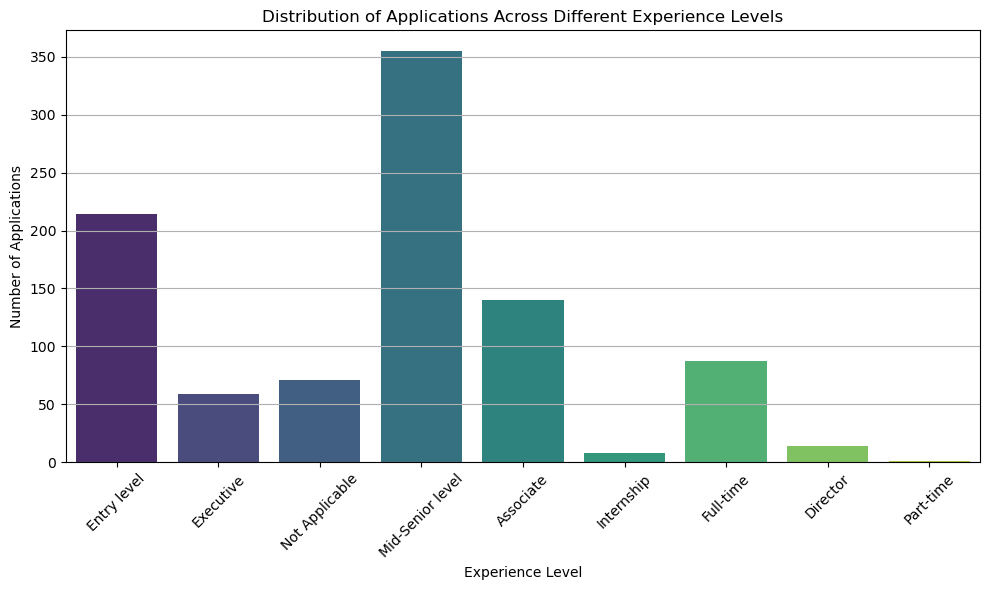

In [30]:
# Create a count plot to visualize the distribution of applications across different experience levels
plt.figure(figsize=(10, 6))
sns.countplot(x='experienceLevel', data=data, palette='viridis')
plt.title('Distribution of Applications Across Different Experience Levels')
plt.xlabel('Experience Level')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y')  # Add grid lines on y-axis
plt.tight_layout()
plt.show()

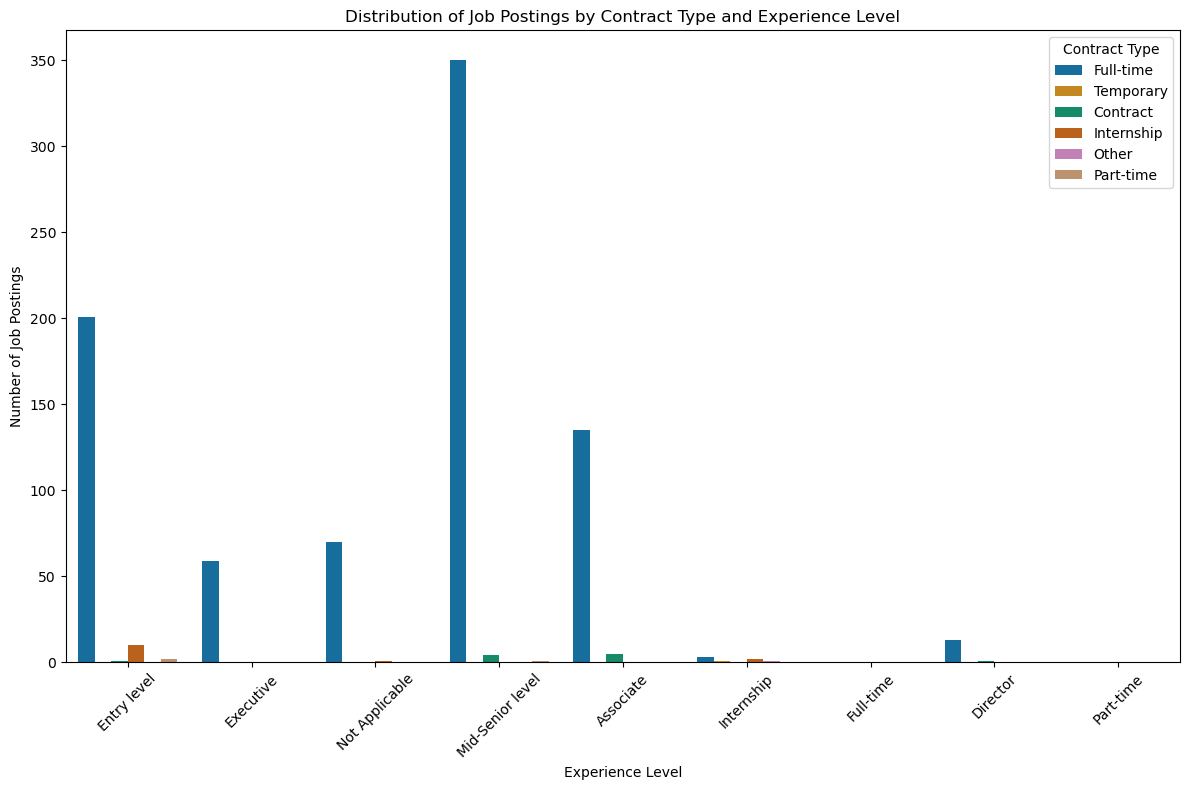

In [31]:
# Create a grouped bar chart to visualize the distribution of job postings by contract type and experience level
plt.figure(figsize=(12, 8))
sns.countplot(data=data, x='experienceLevel', hue='contractType', palette='colorblind')
plt.title('Distribution of Job Postings by Contract Type and Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Contract Type')
plt.tight_layout()
plt.show()